In [1]:
import torch
torch.cuda.empty_cache()

In [2]:
!pip install timm albumentations scikit-learn

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
from torch import amp

In [4]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/finally_multimodel_IFND_is_cleaned.csv"
IMAGE_FOLDER = "/content/drive/MyDrive/final_images"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
df = pd.read_csv(DATA_PATH)

df['Label'] = df['Label'].astype(str).str.strip().str.lower()
df['Label'] = df['Label'].map({'true': 1, 'false': 0})

In [6]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['Label'], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['Label'], random_state=42
)

print(len(train_df), len(val_df), len(test_df))

20673 4430 4430


In [7]:
train_transform = A.Compose([
    A.Resize(224,224),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussianBlur(p=0.2),
    A.ImageCompression(quality_lower=60, quality_upper=100, p=0.3),
    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2()
])

val_test_transform = A.Compose([
    A.Resize(224,224),
    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2()
])

/tmp/ipython-input-2619853583.py:6: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=60, quality_upper=100, p=0.3),


In [8]:
class SwinDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['image_path'].split('/')[-1]
        img_path = os.path.join(IMAGE_FOLDER, img_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image=image)['image']

        label = torch.tensor(row['Label'], dtype=torch.float32)
        return image, label

In [9]:
train_loader = DataLoader(SwinDataset(train_df, train_transform),
                          batch_size=16, shuffle=True, num_workers=2)

val_loader = DataLoader(SwinDataset(val_df, val_test_transform),
                        batch_size=16, shuffle=False, num_workers=2)

test_loader = DataLoader(SwinDataset(test_df, val_test_transform),
                         batch_size=16, shuffle=False, num_workers=2)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model(
    'swin_small_patch4_window7_224',
    pretrained=True,
    num_classes=1
)

# Enable gradient checkpointing (saves memory)
model.set_grad_checkpointing(True)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [11]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

scaler = amp.GradScaler()

In [12]:
def train_model(model, train_loader, val_loader, epochs=20):

    best_auc = 0
    patience = 3
    trigger = 0

    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with amp.autocast(device_type='cuda'):
                outputs = model(images).squeeze(1)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()

        scheduler.step()

        # Validation
        model.eval()
        all_labels = []
        all_probs = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                outputs = model(images).squeeze(1)
                probs = torch.sigmoid(outputs).cpu().numpy()

                all_probs.extend(probs)
                all_labels.extend(labels.numpy())

        roc_auc = roc_auc_score(all_labels, all_probs)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | Val AUC: {roc_auc:.4f}")

        if roc_auc > best_auc:
            best_auc = roc_auc
            torch.save(model.state_dict(),
                       "/content/drive/MyDrive/best_swin_model.pth")
            print("Best model saved")
            trigger = 0
        else:
            trigger += 1
            if trigger >= patience:
                print("Early stopping triggered")
                break

    print("Best Validation AUC:", best_auc)

In [13]:
train_model(model, train_loader, val_loader, epochs=20)

Epoch 1/20 | Loss: 0.5356 | Val AUC: 0.7317
Best model saved
Epoch 2/20 | Loss: 0.4895 | Val AUC: 0.7394
Best model saved
Epoch 3/20 | Loss: 0.4594 | Val AUC: 0.7462
Best model saved
Epoch 4/20 | Loss: 0.4159 | Val AUC: 0.7496
Best model saved
Epoch 5/20 | Loss: 0.3631 | Val AUC: 0.7432
Epoch 6/20 | Loss: 0.3188 | Val AUC: 0.7545
Best model saved
Epoch 7/20 | Loss: 0.2885 | Val AUC: 0.7504
Epoch 8/20 | Loss: 0.2600 | Val AUC: 0.7502
Epoch 9/20 | Loss: 0.2427 | Val AUC: 0.7478
Early stopping triggered
Best Validation AUC: 0.754488235972355


In [14]:
model.load_state_dict(
    torch.load("/content/drive/MyDrive/best_swin_model.pth")
)

model.eval()

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

In [15]:
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        probs = torch.sigmoid(outputs).cpu().numpy()

        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

all_preds = (np.array(all_probs) > 0.5).astype(int)

print("===== TEST RESULTS =====")
print("Accuracy:", accuracy_score(all_labels, all_preds))
print("Precision:", precision_score(all_labels, all_preds))
print("Recall:", recall_score(all_labels, all_preds))
print("F1:", f1_score(all_labels, all_preds))
print("ROC AUC:", roc_auc_score(all_labels, all_probs))

===== TEST RESULTS =====
Accuracy: 0.7616252821670428
Precision: 0.7930413917216557
Recall: 0.878405315614618
F1: 0.8335435056746532
ROC AUC: 0.743298044078424


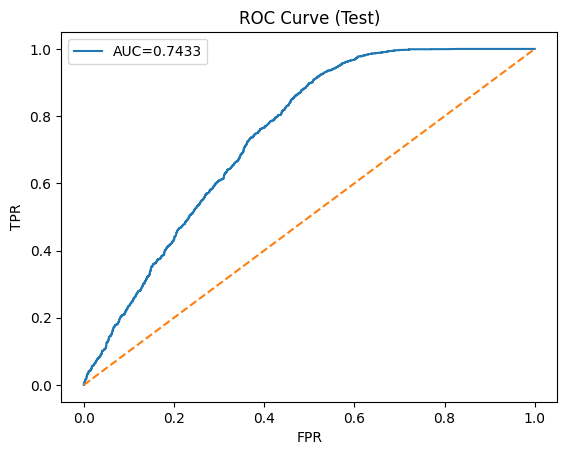

In [16]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(all_labels, all_probs):.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (Test)")
plt.legend()
plt.show()